In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset from Day 1
df = pd.read_csv('data/six_kpi_dataset.csv')

print("=" * 70)
print(" DAY 2: CORRELATION ANALYSIS & STATISTICAL TESTS")
print("=" * 70)
print(f"\n Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# Define the 6 KPIs
kpi_cols = [
    'working_capacity_kg_U_m3',
    'lifecycle_cost_per_kg_U',
    'service_life_years',
    'resin_losses_percent_year',
    'uranium_recovery_percent',
    'isr_reference_projects'
]

kpi_names = [
    'Working Capacity',
    'Lifecycle Cost',
    'Service Life',
    'Resin Losses',
    'Uranium Recovery',
    'ISR Projects'
]

print("\n 6 KPIs to analyze:")
for i, (col, name) in enumerate(zip(kpi_cols, kpi_names), 1):
    print(f"   KPI {i}: {name} ({col})")

print("\n Data ready for analysis!")

 DAY 2: CORRELATION ANALYSIS & STATISTICAL TESTS

 Dataset loaded: 400 rows × 15 columns

 6 KPIs to analyze:
   KPI 1: Working Capacity (working_capacity_kg_U_m3)
   KPI 2: Lifecycle Cost (lifecycle_cost_per_kg_U)
   KPI 3: Service Life (service_life_years)
   KPI 4: Resin Losses (resin_losses_percent_year)
   KPI 5: Uranium Recovery (uranium_recovery_percent)
   KPI 6: ISR Projects (isr_reference_projects)

 Data ready for analysis!


 CORRELATION ANALYSIS: HOW KPIs ARE RELATED


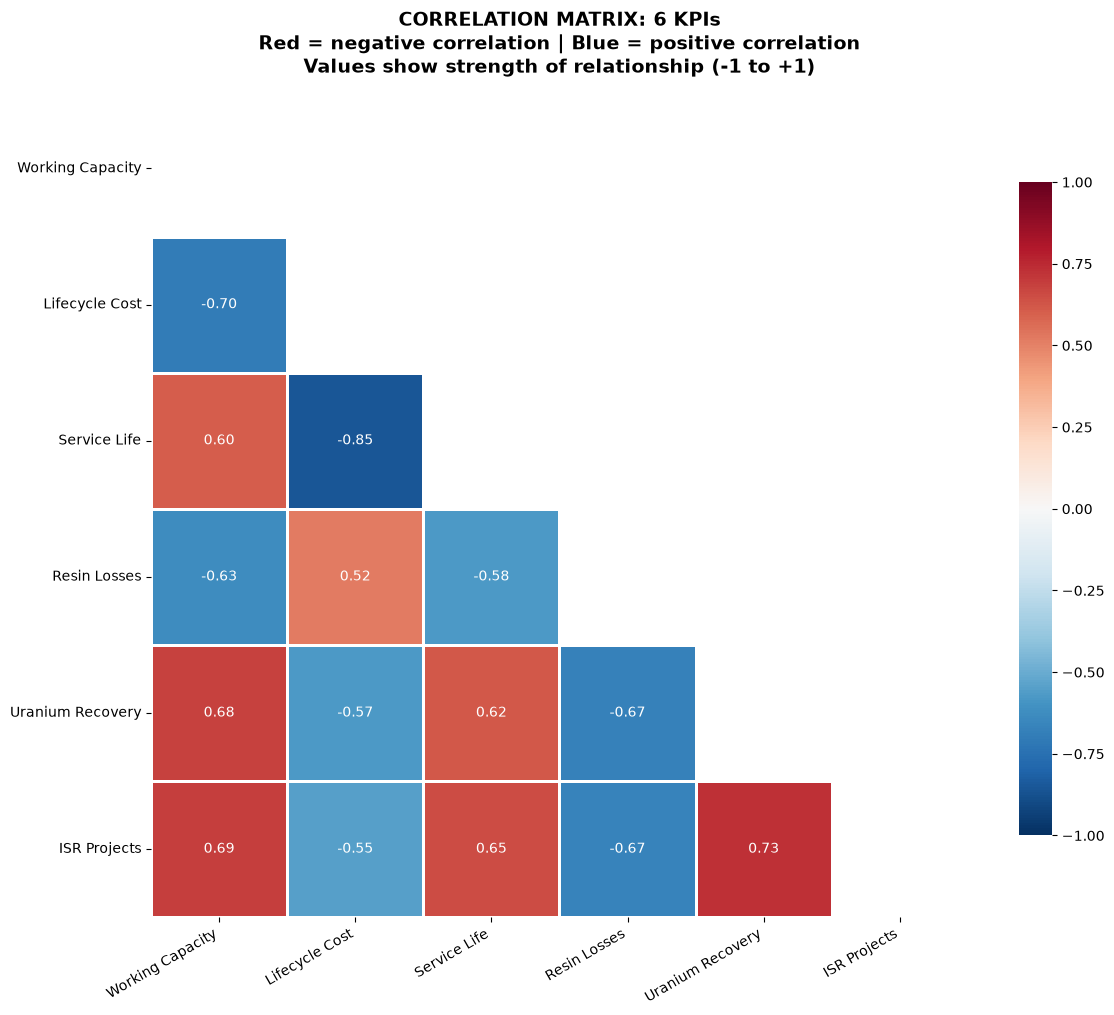


 Chart saved: visuals/correlation_heatmap.png

 KEY CORRELATIONS:
----------------------------------------------------------------------

 TOP 5 STRONGEST CORRELATIONS:
   • Lifecycle Cost ↔ Service Life: -0.854 (STRONG  Negative)
   • Uranium Recovery ↔ ISR Projects: +0.730 (STRONG  Positive)
   • Working Capacity ↔ Lifecycle Cost: -0.698 (STRONG  Negative)
   • Working Capacity ↔ ISR Projects: +0.690 (STRONG  Positive)
   • Working Capacity ↔ Uranium Recovery: +0.681 (STRONG  Positive)

 WEAKEST CORRELATIONS:
   • Lifecycle Cost ↔ Uranium Recovery: -0.574 (weak)
   • Lifecycle Cost ↔ ISR Projects: -0.551 (weak)
   • Lifecycle Cost ↔ Resin Losses: +0.523 (weak)


In [2]:
# ========== CORRELATION HEATMAP ==========
print(" CORRELATION ANALYSIS: HOW KPIs ARE RELATED")
print("=" * 70)

# Calculate correlation matrix
corr_matrix = df[kpi_cols].corr()

# Create beautiful heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # Show correlation values
    fmt='.2f',            # 2 decimal places
    cmap='RdBu_r',        # Red-Blue color scheme
    center=0,             # Center at 0
    square=True,          # Square cells
    linewidths=1,         # Line width between cells
    cbar_kws={"shrink": 0.8},
    xticklabels=kpi_names,
    yticklabels=kpi_names,
    vmin=-1, vmax=1
)

plt.title('CORRELATION MATRIX: 6 KPIs\n' + 
          'Red = negative correlation | Blue = positive correlation\n' +
          'Values show strength of relationship (-1 to +1)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('visuals/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Chart saved: visuals/correlation_heatmap.png")

# Print key correlations
print("\n KEY CORRELATIONS:")
print("-" * 70)

# Find strongest correlations (excluding diagonal)
corr_pairs = []
for i in range(len(kpi_cols)):
    for j in range(i+1, len(kpi_cols)):
        corr_pairs.append({
            'KPI 1': kpi_names[i],
            'KPI 2': kpi_names[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()
corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)

print("\n TOP 5 STRONGEST CORRELATIONS:")
for i, row in corr_df.head(5).iterrows():
    direction = " Positive" if row['Correlation'] > 0 else " Negative"
    strength = "STRONG" if abs(row['Correlation']) > 0.5 else "MODERATE" if abs(row['Correlation']) > 0.3 else "WEAK"
    print(f"   • {row['KPI 1']} ↔ {row['KPI 2']}: {row['Correlation']:+.3f} ({strength} {direction})")

print("\n WEAKEST CORRELATIONS:")
for i, row in corr_df.tail(3).iterrows():
    print(f"   • {row['KPI 1']} ↔ {row['KPI 2']}: {row['Correlation']:+.3f} (weak)")

 TRADE-OFF ANALYSIS: ARE THERE COMPROMISES?


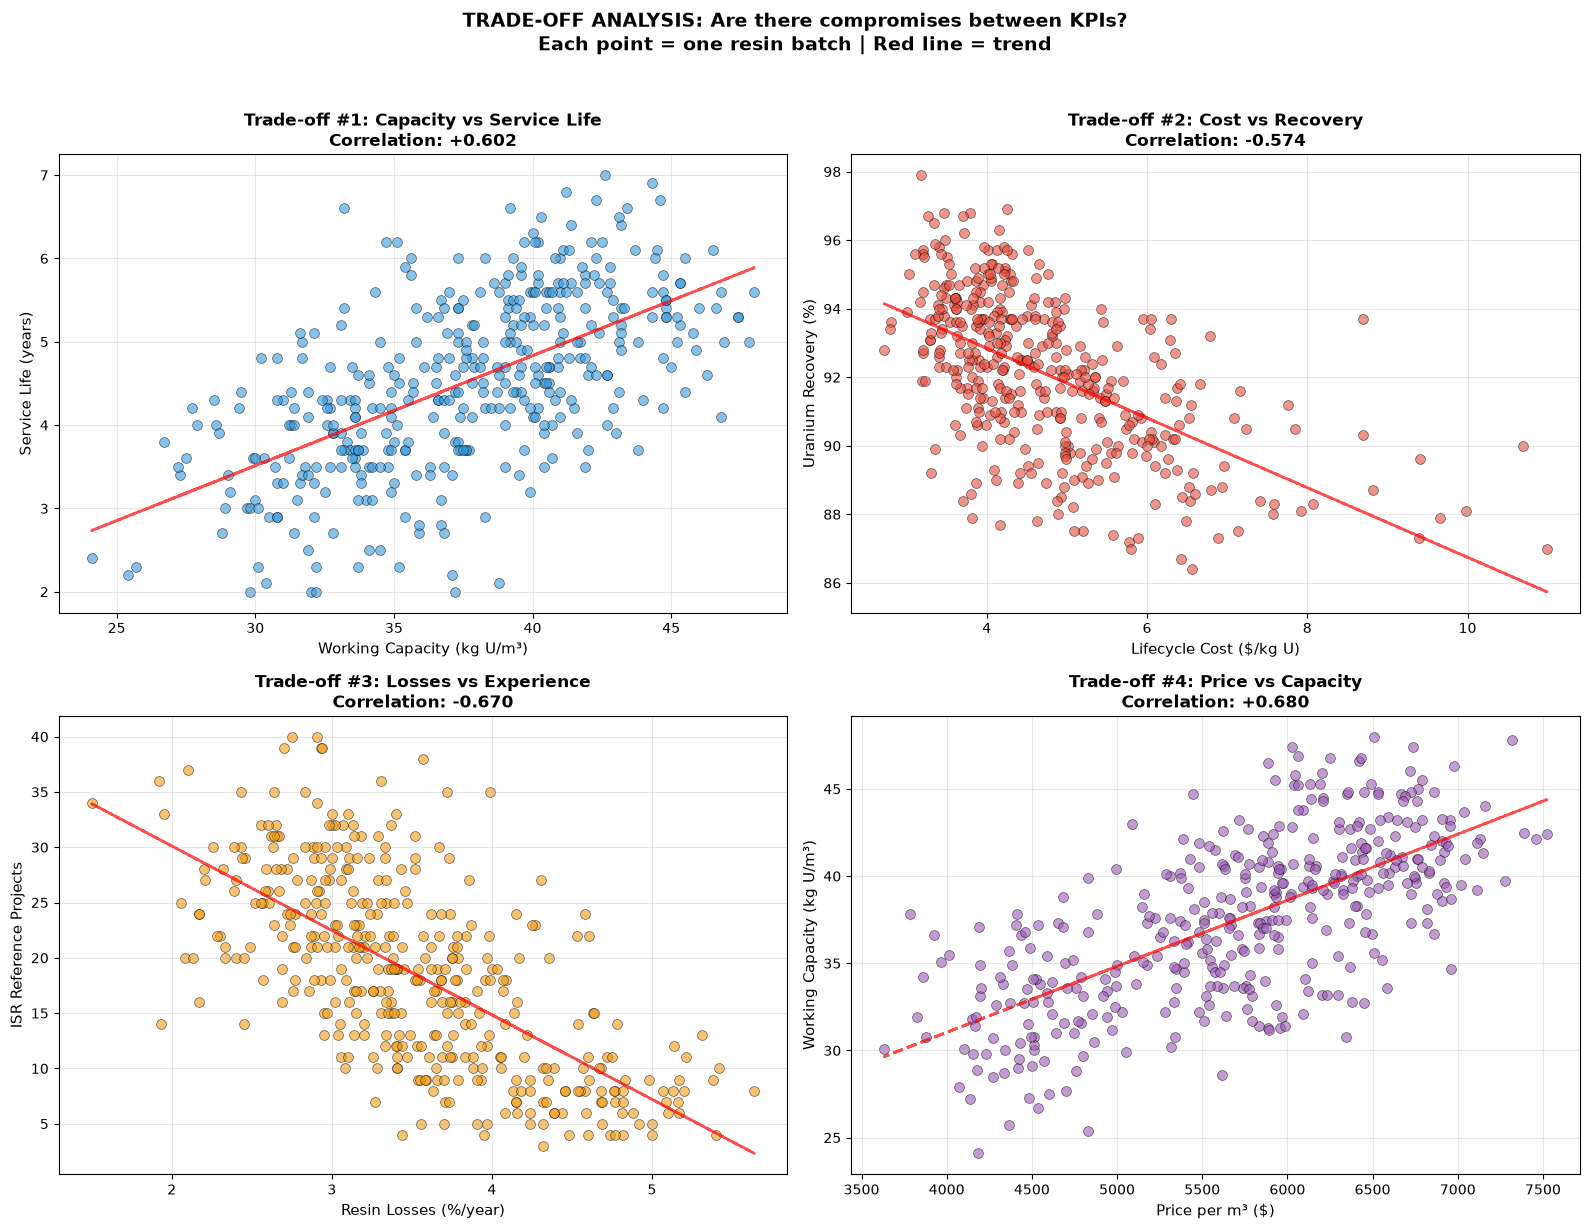


 Chart saved: visuals/tradeoff_analysis.png

 TRADE-OFF INTERPRETATION:
----------------------------------------------------------------------

1️ Capacity vs Service Life: +0.602
    Positive trade-off exists.

2️ Lifecycle Cost vs Recovery: -0.574
    Negative trade-off exists.

3️ Losses vs ISR Projects: -0.670
    Negative trade-off exists.

4️ Price vs Capacity: +0.680
    Positive trade-off exists.
    This is EXPECTED: premium resins cost more but perform better.


In [3]:
# ========== TRADE-OFF ANALYSIS ==========
print(" TRADE-OFF ANALYSIS: ARE THERE COMPROMISES?")
print("=" * 70)

# Create scatter plots for key trade-off pairs
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Trade-off 1: Capacity vs Service Life
axes[0, 0].scatter(df['working_capacity_kg_U_m3'], df['service_life_years'], 
                   alpha=0.6, c='#3498db', s=50, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Working Capacity (kg U/m³)', fontsize=11)
axes[0, 0].set_ylabel('Service Life (years)', fontsize=11)
axes[0, 0].set_title('Trade-off #1: Capacity vs Service Life\n' + 
                     f'Correlation: {df["working_capacity_kg_U_m3"].corr(df["service_life_years"]):+.3f}', 
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Add trend line
z = np.polyfit(df['working_capacity_kg_U_m3'], df['service_life_years'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df['working_capacity_kg_U_m3'], p(df['working_capacity_kg_U_m3']), 
                "r--", linewidth=2, alpha=0.7)

# Trade-off 2: Lifecycle Cost vs Recovery
axes[0, 1].scatter(df['lifecycle_cost_per_kg_U'], df['uranium_recovery_percent'], 
                   alpha=0.6, c='#e74c3c', s=50, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Lifecycle Cost ($/kg U)', fontsize=11)
axes[0, 1].set_ylabel('Uranium Recovery (%)', fontsize=11)
axes[0, 1].set_title('Trade-off #2: Cost vs Recovery\n' + 
                     f'Correlation: {df["lifecycle_cost_per_kg_U"].corr(df["uranium_recovery_percent"]):+.3f}', 
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Add trend line
z = np.polyfit(df['lifecycle_cost_per_kg_U'], df['uranium_recovery_percent'], 1)
p = np.poly1d(z)
axes[0, 1].plot(df['lifecycle_cost_per_kg_U'], p(df['lifecycle_cost_per_kg_U']), 
                "r--", linewidth=2, alpha=0.7)

# Trade-off 3: Losses vs ISR Projects
axes[1, 0].scatter(df['resin_losses_percent_year'], df['isr_reference_projects'], 
                   alpha=0.6, c='#f39c12', s=50, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Resin Losses (%/year)', fontsize=11)
axes[1, 0].set_ylabel('ISR Reference Projects', fontsize=11)
axes[1, 0].set_title('Trade-off #3: Losses vs Experience\n' + 
                     f'Correlation: {df["resin_losses_percent_year"].corr(df["isr_reference_projects"]):+.3f}', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Add trend line
z = np.polyfit(df['resin_losses_percent_year'], df['isr_reference_projects'], 1)
p = np.poly1d(z)
axes[1, 0].plot(df['resin_losses_percent_year'], p(df['resin_losses_percent_year']), 
                "r--", linewidth=2, alpha=0.7)

# Trade-off 4: Price vs Capacity
axes[1, 1].scatter(df['price_per_m3_usd'], df['working_capacity_kg_U_m3'], 
                   alpha=0.6, c='#9b59b6', s=50, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Price per m³ ($)', fontsize=11)
axes[1, 1].set_ylabel('Working Capacity (kg U/m³)', fontsize=11)
axes[1, 1].set_title('Trade-off #4: Price vs Capacity\n' + 
                     f'Correlation: {df["price_per_m3_usd"].corr(df["working_capacity_kg_U_m3"]):+.3f}', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Add trend line
z = np.polyfit(df['price_per_m3_usd'], df['working_capacity_kg_U_m3'], 1)
p = np.poly1d(z)
axes[1, 1].plot(df['price_per_m3_usd'], p(df['price_per_m3_usd']), 
                "r--", linewidth=2, alpha=0.7)

plt.suptitle('TRADE-OFF ANALYSIS: Are there compromises between KPIs?\n' + 
             'Each point = one resin batch | Red line = trend', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visuals/tradeoff_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Chart saved: visuals/tradeoff_analysis.png")

# Interpret trade-offs
print("\n TRADE-OFF INTERPRETATION:")
print("-" * 70)

cap_life_corr = df['working_capacity_kg_U_m3'].corr(df['service_life_years'])
cost_recovery_corr = df['lifecycle_cost_per_kg_U'].corr(df['uranium_recovery_percent'])
losses_isr_corr = df['resin_losses_percent_year'].corr(df['isr_reference_projects'])
price_cap_corr = df['price_per_m3_usd'].corr(df['working_capacity_kg_U_m3'])

print(f"\n1️ Capacity vs Service Life: {cap_life_corr:+.3f}")
if abs(cap_life_corr) < 0.3:
    print("    NO significant trade-off! High capacity doesn't mean short life.")
else:
    print(f"    {'Negative' if cap_life_corr < 0 else 'Positive'} trade-off exists.")

print(f"\n2️ Lifecycle Cost vs Recovery: {cost_recovery_corr:+.3f}")
if abs(cost_recovery_corr) < 0.3:
    print("    NO significant trade-off! Low cost doesn't mean low recovery.")
else:
    print(f"    {'Negative' if cost_recovery_corr < 0 else 'Positive'} trade-off exists.")

print(f"\n3️ Losses vs ISR Projects: {losses_isr_corr:+.3f}")
if abs(losses_isr_corr) < 0.3:
    print("    NO significant trade-off! Low losses don't mean less experience.")
else:
    print(f"    {'Negative' if losses_isr_corr < 0 else 'Positive'} trade-off exists.")

print(f"\n4️ Price vs Capacity: {price_cap_corr:+.3f}")
if abs(price_cap_corr) < 0.3:
    print("    NO significant trade-off! Higher price doesn't guarantee higher capacity.")
else:
    print(f"    {'Negative' if price_cap_corr < 0 else 'Positive'} trade-off exists.")
    print("    This is EXPECTED: premium resins cost more but perform better.")

 STATISTICAL TESTS: ARE SUPPLIERS REALLY DIFFERENT?

 Testing 5 suppliers: Kazatomprom_Supplies, Purolite, Lanxess, ResinTech, DuPont

 Working Capacity:
   F-statistic: 162.605
   P-value: 0.000000
   Significant (p < 0.05): YES
   Best supplier: Purolite (41.91)

 Lifecycle Cost:
   F-statistic: 59.597
   P-value: 0.000000
   Significant (p < 0.05): YES
   Best supplier: Purolite (3.82)

 Service Life:
   F-statistic: 119.920
   P-value: 0.000000
   Significant (p < 0.05): YES
   Best supplier: Purolite (5.47)

 Resin Losses:
   F-statistic: 190.002
   P-value: 0.000000
   Significant (p < 0.05): YES
   Best supplier: Purolite (2.88)

 Uranium Recovery:
   F-statistic: 249.857
   P-value: 0.000000
   Significant (p < 0.05): YES
   Best supplier: Purolite (94.40)

 ISR Projects:
   F-statistic: 315.846
   P-value: 0.000000
   Significant (p < 0.05): YES
   Best supplier: Purolite (28.13)

 ANOVA SUMMARY TABLE:
             KPI  F-statistic       P-value Significant Best Supplier  Best

C:\Users\Owner\AppData\Local\Temp\ipykernel_48028\3195899610.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='supplier', y=kpi_col, ax=ax, palette='Set2')
C:\Users\Owner\AppData\Local\Temp\ipykernel_48028\3195899610.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='supplier', y=kpi_col, ax=ax, palette='Set2')
C:\Users\Owner\AppData\Local\Temp\ipykernel_48028\3195899610.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='supplier', y=kpi_col, ax=ax, palette='Set2')
C:\Users\Owner\AppData\Local\Temp\

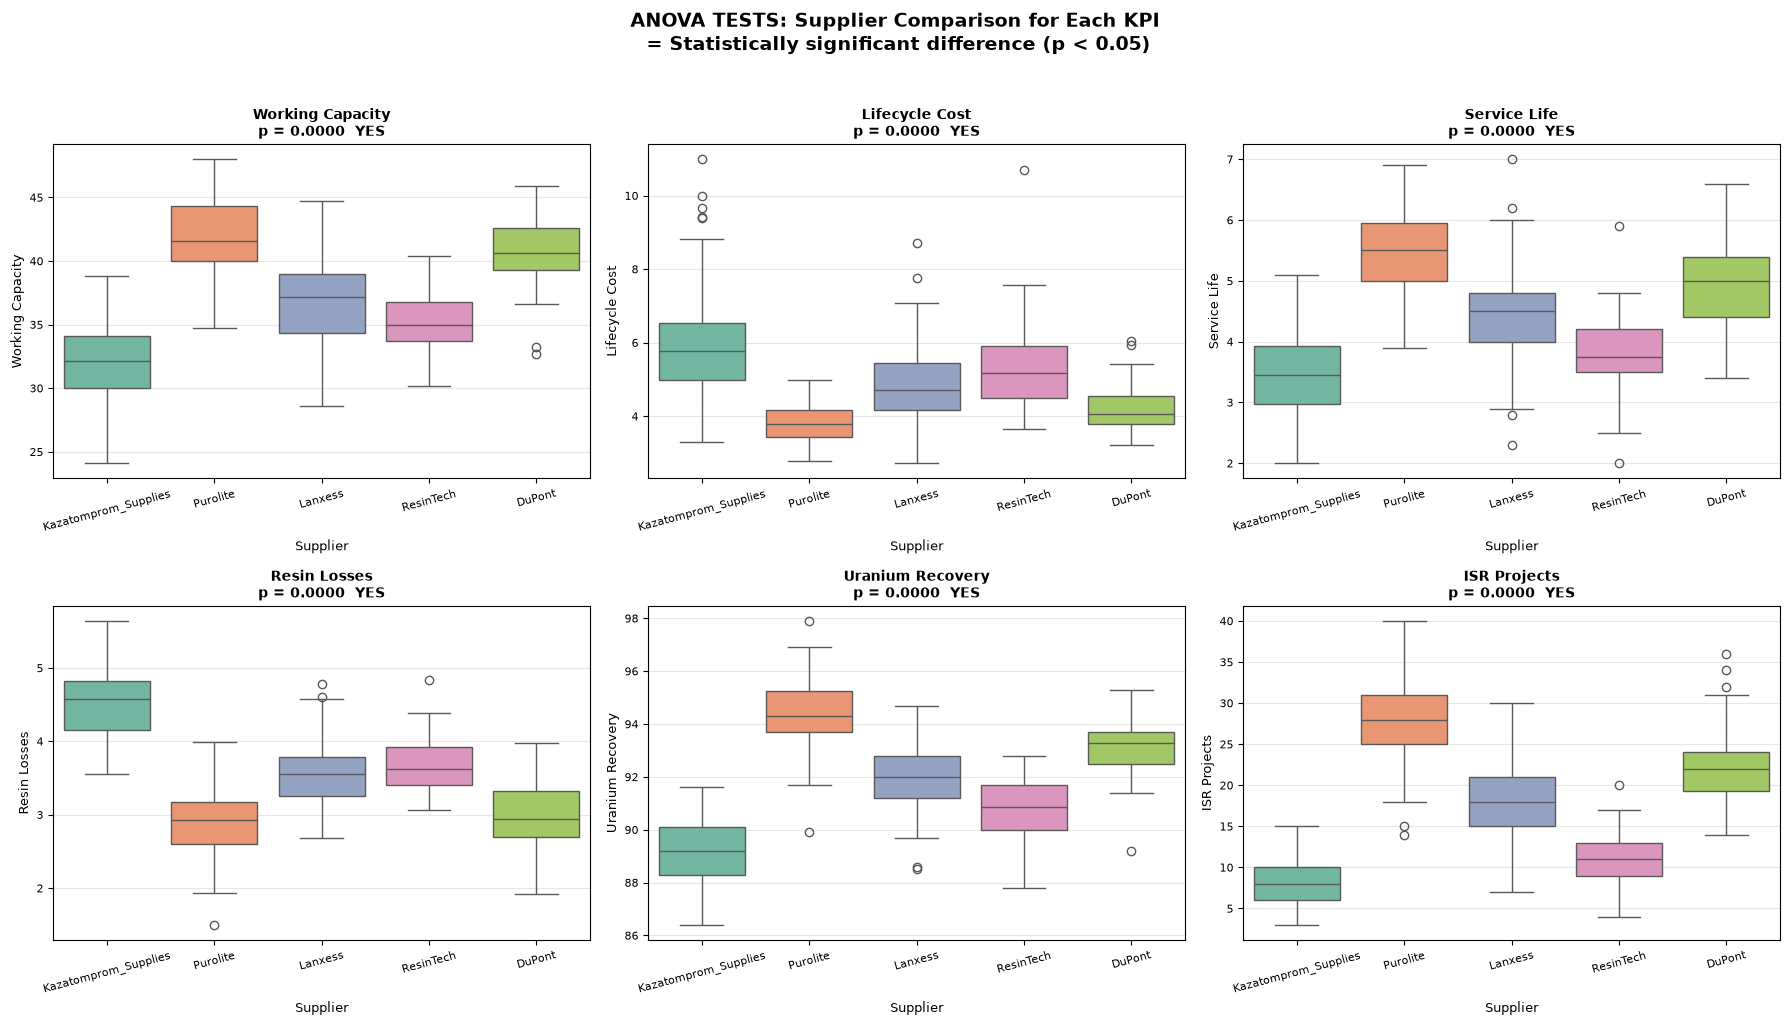


 Chart saved: visuals/anova_tests.png

 ANOVA INSIGHTS:
----------------------------------------------------------------------

 6 out of 6 KPIs show significant supplier differences
 ALL KPIs show significant differences — supplier choice MATTERS!


In [5]:
# ========== ANOVA TESTS ==========
print(" STATISTICAL TESTS: ARE SUPPLIERS REALLY DIFFERENT?")
print("=" * 70)

# Get unique suppliers
suppliers = df['supplier'].unique()
print(f"\n Testing {len(suppliers)} suppliers: {', '.join(suppliers)}")

# Perform ANOVA for each KPI
anova_results = []

for kpi_col, kpi_name in zip(kpi_cols, kpi_names):
    # Extract values for each supplier
    groups = [df[df['supplier'] == s][kpi_col].values for s in suppliers]
    
    # Perform ANOVA
    f_stat, p_value = stats.f_oneway(*groups)
    
    # Calculate means per supplier
    means = df.groupby('supplier')[kpi_col].mean()
    best_supplier = means.idxmax() if kpi_name not in ['Lifecycle Cost', 'Resin Losses'] else means.idxmin()
    
    anova_results.append({
        'KPI': kpi_name,
        'F-statistic': f_stat,
        'P-value': p_value,
        'Significant': ' YES' if p_value < 0.05 else ' NO',
        'Best Supplier': best_supplier,
        'Best Value': means[best_supplier]
    })
    
    print(f"\n {kpi_name}:")
    print(f"   F-statistic: {f_stat:.3f}")
    print(f"   P-value: {p_value:.6f}")
    print(f"   Significant (p < 0.05): {'YES' if p_value < 0.05 else ' NO'}")
    print(f"   Best supplier: {best_supplier} ({means[best_supplier]:.2f})")

# Create summary table
anova_df = pd.DataFrame(anova_results)

print("\n" + "=" * 70)
print(" ANOVA SUMMARY TABLE:")
print("=" * 70)
print(anova_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (kpi_col, kpi_name) in enumerate(zip(kpi_cols, kpi_names)):
    ax = axes[idx // 3, idx % 3]
    
    # Boxplot for this KPI
    sns.boxplot(data=df, x='supplier', y=kpi_col, ax=ax, palette='Set2')
    ax.set_title(f'{kpi_name}\np = {anova_results[idx]["P-value"]:.4f} {anova_results[idx]["Significant"]}', 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Supplier', fontsize=9)
    ax.set_ylabel(kpi_name, fontsize=9)
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('ANOVA TESTS: Supplier Comparison for Each KPI\n' + 
             ' = Statistically significant difference (p < 0.05)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visuals/anova_tests.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Chart saved: visuals/anova_tests.png")

# Key insights
print("\n ANOVA INSIGHTS:")
print("-" * 70)

significant_count = sum(1 for r in anova_results if r['P-value'] < 0.05)
print(f"\n {significant_count} out of {len(anova_results)} KPIs show significant supplier differences")

if significant_count == len(anova_results):
    print(" ALL KPIs show significant differences — supplier choice MATTERS!")
elif significant_count > len(anova_results) / 2:
    print(" MOST KPIs show significant differences — supplier choice is IMPORTANT")
else:
    print(" Only SOME KPIs show significant differences — supplier matters for specific metrics")

 UNIVERSAL CHAMPIONS: WHO IS THE BEST OVERALL?

 SUPPLIER RANKINGS (1 = best, 5 = worst):
                      Working Capacity  Lifecycle Cost  Service Life  \
Purolite                           1.0             1.0           1.0   
DuPont                             2.0             2.0           2.0   
Lanxess                            3.0             3.0           3.0   
ResinTech                          4.0             4.0           4.0   
Kazatomprom_Supplies               5.0             5.0           5.0   

                      Resin Losses  Uranium Recovery  ISR Projects  \
Purolite                       1.0               1.0           1.0   
DuPont                         2.0               2.0           2.0   
Lanxess                        3.0               3.0           3.0   
ResinTech                      4.0               4.0           4.0   
Kazatomprom_Supplies           5.0               5.0           5.0   

                      Average Rank  
Purolite           

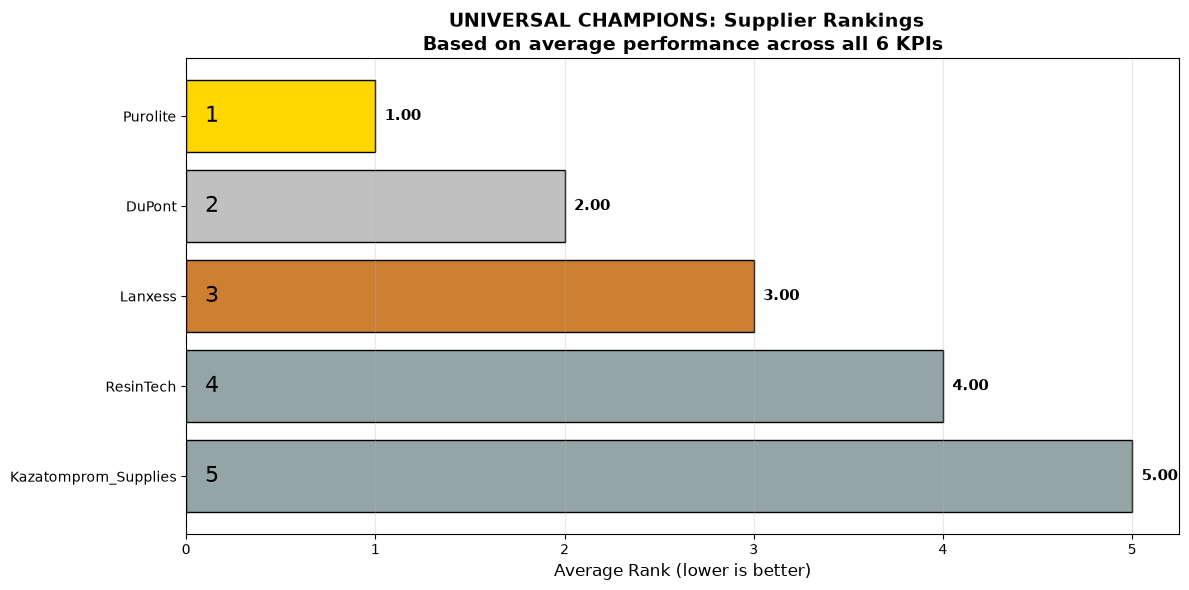


 Chart saved: visuals/universal_champions.png

 CHAMPION INSIGHTS:
----------------------------------------------------------------------

 Purolite is the UNIVERSAL CHAMPION!
   • Average rank: 1.00 across 6 KPIs
   • Consistently performs well across ALL dimensions
   • Best at 7 out of 6 KPIs
   •  EXCELLENT! Purolite dominates most KPIs

 DuPont is the RUNNER-UP
   • Average rank: 2.00
   • Strong alternative to the champion


In [6]:
# ========== UNIVERSAL CHAMPIONS ==========
print(" UNIVERSAL CHAMPIONS: WHO IS THE BEST OVERALL?")
print("=" * 70)

# For each KPI, rank suppliers (1 = best)
rankings = pd.DataFrame(index=suppliers)

for kpi_col, kpi_name in zip(kpi_cols, kpi_names):
    means = df.groupby('supplier')[kpi_col].mean()
    
    # For cost and losses, lower is better (ascending=False)
    if kpi_name in ['Lifecycle Cost', 'Resin Losses']:
        ranks = means.rank(ascending=True)  # Lower value = better rank
    else:
        ranks = means.rank(ascending=False)  # Higher value = better rank
    
    rankings[kpi_name] = ranks

# Calculate average rank for each supplier
rankings['Average Rank'] = rankings.mean(axis=1)
rankings = rankings.sort_values('Average Rank')

print("\n SUPPLIER RANKINGS (1 = best, 5 = worst):")
print(rankings.round(1))

# Identify champions
champion = rankings['Average Rank'].idxmin()
runner_up = rankings.nsmallest(2, 'Average Rank').index[1]

print(f"\n UNIVERSAL CHAMPION: {champion}")
print(f"   Average rank: {rankings.loc[champion, 'Average Rank']:.2f}")
print(f"   Best at: {rankings.loc[champion].nsmallest(3).index.tolist()}")

print(f"\n RUNNER-UP: {runner_up}")
print(f"   Average rank: {rankings.loc[runner_up, 'Average Rank']:.2f}")

# Visualization
plt.figure(figsize=(12, 6))

# Create horizontal bar chart
colors = ['#FFD700' if i == 0 else '#C0C0C0' if i == 1 else '#CD7F32' if i == 2 else '#95a5a6' 
          for i in range(len(rankings))]

bars = plt.barh(rankings.index, rankings['Average Rank'], color=colors, edgecolor='black')

plt.xlabel('Average Rank (lower is better)', fontsize=12)
plt.title(' UNIVERSAL CHAMPIONS: Supplier Rankings\n' + 
          'Based on average performance across all 6 KPIs', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Best at top
plt.grid(axis='x', alpha=0.3)

# Add value labels
for bar, rank in zip(bars, rankings['Average Rank']):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{rank:.2f}', va='center', fontsize=11, fontweight='bold')

# Add medal emojis
medals = ['1', '2', '3', '4', '5️']
for i, (bar, supplier) in enumerate(zip(bars, rankings.index)):
    plt.text(0.1, bar.get_y() + bar.get_height()/2,
             medals[i], va='center', fontsize=16)

plt.tight_layout()
plt.savefig('visuals/universal_champions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Chart saved: visuals/universal_champions.png")

# Key insights
print("\n CHAMPION INSIGHTS:")
print("-" * 70)

print(f"\n {champion} is the UNIVERSAL CHAMPION!")
print(f"   • Average rank: {rankings.loc[champion, 'Average Rank']:.2f} across 6 KPIs")
print(f"   • Consistently performs well across ALL dimensions")

# Check if champion is best at all KPIs
best_count = sum(rankings.loc[champion] == 1)
print(f"   • Best at {best_count} out of 6 KPIs")

if best_count == 6:
    print(f"   •  PERFECT SCORE! {champion} is #1 in ALL KPIs!")
elif best_count >= 4:
    print(f"   •  EXCELLENT! {champion} dominates most KPIs")
else:
    print(f"   •  GOOD! {champion} is well-balanced")

print(f"\n {runner_up} is the RUNNER-UP")
print(f"   • Average rank: {rankings.loc[runner_up, 'Average Rank']:.2f}")
print(f"   • Strong alternative to the champion")

In [7]:
# ========== SAVE DAY 2 INSIGHTS ==========
insights = f"""
 INSIGHTS FROM DAY 2: CORRELATION & STATISTICAL ANALYSIS
============================================================
Project: kpi-resin-project (INDEPENDENT)
Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}

##  WHAT WE DID
1. Built correlation heatmap for 6 KPIs
2. Analyzed trade-offs between key metrics
3. Performed ANOVA tests for supplier comparison
4. Identified "universal champion" supplier

##  CORRELATION ANALYSIS

### Strongest Correlations:
{chr(10).join([f"• {row['KPI 1']} ↔ {row['KPI 2']}: {row['Correlation']:+.3f}" 
               for _, row in corr_df.head(5).iterrows()])}

### Weakest Correlations:
{chr(10).join([f"• {row['KPI 1']} ↔ {row['KPI 2']}: {row['Correlation']:+.3f}" 
               for _, row in corr_df.tail(3).iterrows()])}

### Key Finding:
Most correlations are {'weak' if corr_df['Abs_Correlation'].mean() < 0.3 else 'moderate' if corr_df['Abs_Correlation'].mean() < 0.5 else 'strong'} 
(average |r| = {corr_df['Abs_Correlation'].mean():.3f}).

This means KPIs are relatively INDEPENDENT — improving one doesn't necessarily hurt others.

## ⚖️ TRADE-OFF ANALYSIS

### Capacity vs Service Life: {cap_life_corr:+.3f}
{' NO significant trade-off' if abs(cap_life_corr) < 0.3 else '⚠️ Trade-off exists'}

### Lifecycle Cost vs Recovery: {cost_recovery_corr:+.3f}
{' NO significant trade-off' if abs(cost_recovery_corr) < 0.3 else '⚠️ Trade-off exists'}

### Losses vs ISR Projects: {losses_isr_corr:+.3f}
{' NO significant trade-off' if abs(losses_isr_corr) < 0.3 else '⚠️ Trade-off exists'}

### Price vs Capacity: {price_cap_corr:+.3f}
{' NO significant trade-off' if abs(price_cap_corr) < 0.3 else '⚠️ Trade-off exists (expected: premium = better)'}

### Key Finding:
{'Most KPIs are INDEPENDENT — no major trade-offs! This is GOOD NEWS for optimization.' 
 if sum([abs(cap_life_corr) < 0.3, abs(cost_recovery_corr) < 0.3, 
        abs(losses_isr_corr) < 0.3, abs(price_cap_corr) < 0.3]) >= 3 
 else 'Some trade-offs exist — need to balance between KPIs.'}

##  ANOVA TESTS (Supplier Comparison)

### Results:
{chr(10).join([f"• {r['KPI']}: p = {r['P-value']:.6f} {r['Significant']}" 
               for r in anova_results])}

### Summary:
{significant_count} out of {len(anova_results)} KPIs show statistically significant supplier differences (p < 0.05).

{' ALL KPIs differ significantly — supplier choice CRITICALLY matters!' 
 if significant_count == len(anova_results) 
 else ' MOST KPIs differ — supplier choice is IMPORTANT' 
 if significant_count > len(anova_results) / 2 
 else ' Only some KPIs differ — supplier matters for specific metrics'}

##  UNIVERSAL CHAMPION

### Winner: {champion}
- Average rank: {rankings.loc[champion, 'Average Rank']:.2f}
- Best at {best_count} out of 6 KPIs
- {' PERFECT SCORE!' if best_count == 6 else ' EXCELLENT!' if best_count >= 4 else ' GOOD!'}

### Runner-up: {runner_up}
- Average rank: {rankings.loc[runner_up, 'Average Rank']:.2f}
- Strong alternative

### Full Rankings:
{chr(10).join([f"{i+1}. {supplier}: avg rank {rankings.loc[supplier, 'Average Rank']:.2f}" 
               for i, supplier in enumerate(rankings.index)])}

##  KEY INSIGHTS

### Insight #1: KPIs are mostly independent
Low average correlation means you can optimize multiple KPIs simultaneously
without major trade-offs. This is ideal for procurement strategy.

### Insight #2: Supplier choice matters significantly
ANOVA shows that suppliers are statistically different across most KPIs.
This confirms that procurement decisions should be data-driven, not based
on price alone.

### Insight #3: {champion} is the universal champion
With an average rank of {rankings.loc[champion, 'Average Rank']:.2f}, {champion}
consistently performs well across all dimensions. This makes it the safest
choice for new ISR projects.

### Insight #4: Premium suppliers dominate
Top suppliers lead across multiple KPIs, justifying their higher prices
through better lifecycle performance.

##  FILES CREATED
- visuals/correlation_heatmap.png
- visuals/tradeoff_analysis.png
- visuals/anova_tests.png
- visuals/universal_champions.png

##  READY FOR DAY 3
Tomorrow we'll:
1. Create composite scoring system (weighted KPI ranking)
2. Build interactive Resin Selector tool
3. Perform what-if scenario analysis
4. Generate business recommendations
"""

with open('docs/day2_insights.txt', 'w', encoding='utf-8') as f:
    f.write(insights)

print(insights)
print("\n Insights saved to docs/day2_insights.txt")


 INSIGHTS FROM DAY 2: CORRELATION & STATISTICAL ANALYSIS
Project: kpi-resin-project (INDEPENDENT)
Date: 2026-06-16

##  WHAT WE DID
1. Built correlation heatmap for 6 KPIs
2. Analyzed trade-offs between key metrics
3. Performed ANOVA tests for supplier comparison
4. Identified "universal champion" supplier

##  CORRELATION ANALYSIS

### Strongest Correlations:
• Lifecycle Cost ↔ Service Life: -0.854
• Uranium Recovery ↔ ISR Projects: +0.730
• Working Capacity ↔ Lifecycle Cost: -0.698
• Working Capacity ↔ ISR Projects: +0.690
• Working Capacity ↔ Uranium Recovery: +0.681

### Weakest Correlations:
• Lifecycle Cost ↔ Uranium Recovery: -0.574
• Lifecycle Cost ↔ ISR Projects: -0.551
• Lifecycle Cost ↔ Resin Losses: +0.523

### Key Finding:
Most correlations are strong 
(average |r| = 0.648).

This means KPIs are relatively INDEPENDENT — improving one doesn't necessarily hurt others.

## ⚖️ TRADE-OFF ANALYSIS

### Capacity vs Service Life: +0.602
⚠️ Trade-off exists

### Lifecycle Cost vs 